In [12]:
# import library
import pandas as pd 
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt


In [2]:
# load data 
df = pd.read_csv('/home/susan/machine_learning/Data/train_data_houses.csv')
# The following code allows us to display all the coulmns
pd.set_option('display.max_columns', None)
# Now you can see up to 100 rows at once
pd.set_option('display.width', None)
# Keep all rows, drop columns whose names start with "Unnamed"
#c stands for each column name
# it could be named anything, like col or column
df = df.drop(columns=[c for c in df.columns if c.startswith('Unnamed')])
print(df.shape)
print()
print(df.head())
print()
print(df.columns)


(6495, 14)

   last_price  total_area  bedrooms  ceiling_height  floors_total  \
0     56000.0        74.9         1            3.12             2   
1    167000.0       144.1         2            2.77             5   
2    100000.0       117.8         1            2.37            20   
3     96000.0       101.8         2            2.40             5   
4     69000.0        48.7         3            2.65            13   

   living_area  floor  bike_parking  studio  open_plan  kitchen_area  balcony  \
0         31.0      1             0       0          0           6.0        1   
1         79.2      3             1       0          0           4.2        0   
2         51.6     18             0       0          1           8.5        1   
3         66.3      4             0       0          0          14.9        1   
4         21.2      2             0       0          0          13.6        0   

   airport_dist  city_center_dist  
0         27960             16554  
1         4182

In [3]:
# Crete feture and target : 
features = df.drop(['last_price'], axis= 1)
target = df['last_price']
print(features.shape)
print()
print(target.shape)

# split the data 

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)
# Create the model
model = DecisionTreeRegressor(random_state=42)

# Train with .fit()
model.fit(X_train, y_train)

#Predict with .predict()
predictions = model.predict(X_test)
# Evaluate performance
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
print(f"Decision Tree Performance:")
print(f"Mean Squared Error: {mse:,.2f}")
print(f"Root Mean Squared Error: ${rmse:,.2f}")
print()
print("For comparison, Linear Regression achieved:")
print("RMSE: $8,506.09")


(6495, 13)

(6495,)
Decision Tree Performance:
Mean Squared Error: 292,166,281.76
Root Mean Squared Error: $17,092.87

For comparison, Linear Regression achieved:
RMSE: $8,506.09


In [4]:
# Split the data (same split as before)
X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=42
)
# Create and train a Random Forest with only 3 trees
model = RandomForestRegressor(n_estimators = 100, random_state =42)

# Train the model
model. fit(X_train, y_train)

# Make predictions
predictions = model.predict(X_test)

# Calculate performance metrics
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)

print("=== RANDOM FOREST (3 TREES) PERFORMANCE ===")
print(f"Number of trees in forest: {model.n_estimators}")
print(f"Mean Squared Error: {mse:,.2f}")
print(f"Root Mean Squared Error: ${rmse:,.2f}")
print()
print("Previous Models:")
print("Random Forest (3 trees): RMSE:  $11,103.44")
print("Linear Regression RMSE: $8,506.09")
print("Single Decision Tree RMSE: $17,092.87")

=== RANDOM FOREST (3 TREES) PERFORMANCE ===
Number of trees in forest: 100
Mean Squared Error: 123,286,391.92
Root Mean Squared Error: $11,103.44

Previous Models:
Random Forest (3 trees): RMSE:  $11,103.44
Linear Regression RMSE: $8,506.09
Single Decision Tree RMSE: $17,092.87


In [5]:
# Decision Trees and Random Forest for Classification
# DecisionTree Classifier
from sklearn.tree import DecisionTreeClassifier
# same workflow as regression
model = DecisionTreeClassifier(random_state = 42)
model.fit(X_train , y_train)
predictions = model.predict(X_test)

# The evaluation shifts from MSE and RMSE to the classification metrics you learned:
#  accuracy, precision, recall, and F1 score.
#  Hyperparameters for Classification Trees
# Key hyperparameters to control overfitting
dt_classifier = DecisionTreeClassifier(max_depth= 5 , # Limit tree depth 
                                       min_samples_split= 20, # Minimum samples to split a node
                                       min_samples_leaf= 10 , # Minimum samples in each leaf
                                       max_features='sqrt', # Features to consider per split
                                       random_state = 42)
# max_depth: Prevents trees from growing too deep and memorizing noise
# min_samples_split/leaf: Ensures statistical significance in decisions
# max_features: Adds randomness to reduce overfitting
#



In [6]:
# RandomForestClassifier 
# Random forests add ensemble-specific parameters on top of the tree parameters:
from sklearn.ensemble import RandomForestClassifier
# Randomforest hyperparameters
model = RandomForestClassifier( n_estimators = 100, # number of trees ( more better, but slower )
                                       max_depth = 10, # Indivitual tree depth
                                       min_samples_split = 5, # Tree split criteria
                                       max_features= 'sqrt', # features per tree(default for classification)
                                       bootstrap= True, # sampler with replacement
                                       random_state = 42)

# n_estimators: More trees generally improve performance until plateau
# bootstrap: Controls whether trees see different data samples
# max_features: 'sqrt' is typically optimal for classification tasks


In [7]:
# ...existing code...
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

# Accessing Feature Importances
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Get feature importances
importances = rf_model.feature_importances_
feature_names = X_train.columns

# Create readable summary
feature_importance_df = (
    pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    })
    .sort_values('importance', ascending=False)
)

print(feature_importance_df)
# ...existing code...



             feature  importance
0         total_area    0.125576
12  city_center_dist    0.121794
4        living_area    0.115897
11      airport_dist    0.113193
9       kitchen_area    0.104123
2     ceiling_height    0.103775
3       floors_total    0.085625
5              floor    0.078239
1           bedrooms    0.044450
10           balcony    0.038031
8          open_plan    0.026179
6       bike_parking    0.024497
7             studio    0.018621


**What Feature Importance Tells You**

`Feature importance scores (0 to 1, summing to 1.0) reveal:`

* Which features drive predictions most strongly
Potential data quality issues (unexpected important features)
* Domain insights for medical/business understanding
Feature selection opportunities (remove low-importance features)

## Assignments
**1- Train Your First Decision Tree Classifier**

In this task, you'll build your first decision tree classifier to understand how tree-based algorithms work compared to logistic regression. Decision trees make predictions by asking a series of yes/no questions about the features, creating a tree-like structure of decisions that leads to a final prediction.

What you'll do: Create a basic DecisionTreeClassifier, train it on the diabetes dataset, and evaluate its performance using the same metrics you used for logistic regression. This will give you a direct comparison between linear and tree-based approaches.


Your approach: Follow the same three-step machine learning workflow you've learned:

Create the model: Use DecisionTreeClassifier(random_state=42) to ensure reproducible results
Train the model: Use the .fit() method with your training data
Make predictions: Use the .predict() method with your test data
The beauty of scikit-learn is that this workflow remains consistent across all algorithms, making it easy to experiment with different approaches while maintaining the same code structure.

 **2- Optimize Decision Tree with Hyperparameters**
Your basic decision tree might be suffering from overfitting - a common problem where the tree becomes too complex and memorizes the training data instead of learning generalizable patterns. In this task, you'll learn to control this by tuning hyperparameters that limit the tree's complexity.

What you'll do: Create an optimized decision tree using hyperparameters that prevent overfitting. You'll constrain the tree's growth by setting limits on its depth, the number of samples required for splits, and other key parameters that control model complexity.

Understanding the hyperparameters: Each parameter serves a specific purpose in preventing overfitting:

`- max_depth=6`: Limits how deep the tree can grow, preventing it from creating overly complex decision paths
`- min_samples_split=10`: Requires at least 10 samples before the tree can - split a node, preventing splits on very small groups
`- min_samples_leaf=5`: Ensures each final decision (leaf) represents at least 5 samples, avoiding decisions based on just a few data points
- max_features='sqrt': At each split, only considers the square root of total features, adding randomness and reducing overfitting
`- random_state=42`: Ensures your results are reproducible

Your implementation: Create a new DecisionTreeClassifier with these hyperparameters, train it, and compare its performance to your basic tree. Well-tuned hyperparameters often improve generalization even if training performance seems slightly lower.

In [8]:
diabet = pd.read_csv('/home/susan/machine_learning/Data/diabetes.csv')
diabet = diabet.drop(columns=["Unnamed: 0"], errors="ignore")

features = diabet.drop(["Outcome"],axis= 1)
target = diabet["Outcome"]

# splilt data 

X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=42

)

# Creating model and fit
model = DecisionTreeClassifier(random_state= 42)

model.fit(X_train , y_train)
predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
precision = precision_score(y_test, predictions)
recall = recall_score(y_test, predictions)
f1 = f1_score(y_test, predictions)
confusion_mat = confusion_matrix(y_test, predictions)

print("=== DECISION TREE PERFORMANCE ===")
print(f"Accuracy:  {accuracy:.1%}")
print(f"Precision: {precision:.1%}")
print(f"Recall:    {recall:.1%}")
print(f"F1 Score:  {f1:.1%}")
print()
print('======'*30)


#Create a tuned Decision Tree with optimized hyperparameters
model_tuned = DecisionTreeClassifier(max_depth=6, 
                                    min_samples_split=10,
                                    min_samples_leaf=5,
                                    max_features='sqrt',
                                    random_state=42)
# Train the model
model_tuned.fit(X_train, y_train)

# Make predictions
predictions_tuned = model_tuned.predict(X_test)

# Calculate performance metrics
accuracy_tuned = accuracy_score(y_test, predictions_tuned)
precision_tuned = precision_score(y_test, predictions_tuned)
recall_tuned = recall_score(y_test, predictions_tuned)
f1_tuned = f1_score(y_test, predictions_tuned)


print("=== TUNED DECISION TREE PERFORMANCE ===")
print(f"Accuracy:  {accuracy_tuned:.1%}")
print(f"Precision: {precision_tuned:.1%}")
print(f"Recall:    {recall_tuned:.1%}")
print(f"F1 Score:  {f1_tuned:.1%}")
print()
print("Hyperparameters used:")
print(f"Max Depth: {model_tuned.max_depth}")
print(f"Min Samples Split: {model_tuned.min_samples_split}")
print(f"Min Samples Leaf: {model_tuned.min_samples_leaf}")
print(f"Max Features: {model_tuned.max_features}")


=== DECISION TREE PERFORMANCE ===
Accuracy:  74.7%
Precision: 62.5%
Recall:    72.7%
F1 Score:  67.2%

=== TUNED DECISION TREE PERFORMANCE ===
Accuracy:  77.3%
Precision: 65.2%
Recall:    78.2%
F1 Score:  71.1%

Hyperparameters used:
Max Depth: 6
Min Samples Split: 10
Min Samples Leaf: 5
Max Features: sqrt


### Assignments

**1- Train Your Random Forest Classifier**
Now you'll experience the power of ensemble learning by training a Random Forest classifier. Instead of relying on a single decision tree, Random Forest trains many trees (typically 100 by default) and combines their predictions through voting. This approach typically provides more robust and accurate predictions than any single tree.

What you'll do: Create and train a RandomForestClassifier using the same workflow you've mastered. Random Forest builds multiple decision trees, each trained on a slightly different subset of the data and features, then averages their predictions for the final result.

`Why Random Forest works better:`

* Reduces overfitting: Individual trees might overfit, but averaging many trees smooths out these errors
* Handles noise: Random variations in individual trees cancel out when combined
* More stable: Less sensitive to small changes in the training data
Better generalization: Performs more consistently on new, unseen data
* Your implementation: Use RandomForestClassifier(random_state=42) to ensure reproducible results. The default parameters (100 trees) provide a good starting point and should demonstrate the ensemble advantage over single trees.

**2- Optimize Random Forest Performance**
Just like with decision trees, you can fine-tune Random Forest hyperparameters to squeeze out even better performance. In this task, you'll experiment with key parameters that control both the individual trees and how they work together as an ensemble.

`What you'll do`: Create an optimized Random Forest by carefully adjusting hyperparameters that control the number of trees, their individual complexity, and how they sample the data. This demonstrates the iterative process of model optimization that's crucial in real-world machine learning.

Understanding Random Forest hyperparameters:

* n_estimators=200: Use 200 trees instead of 100 for potentially better performance (more trees = more stable predictions, but longer training time)
* max_depth=10: Allow trees to be deeper than in your single decision tree, since Random Forest's averaging reduces overfitting risk
* min_samples_split=5: Allow smaller splits than in single trees because ensemble averaging provides protection against overfitting
* min_samples_leaf=2: Permit smaller leaf nodes for more detailed decision boundaries
* max_features='sqrt': At each split, randomly consider only the square root of features, adding diversity between trees
* random_state=42: Maintain reproducibility for consistent comparisons
Your approach: Build the optimized classifier with these parameters, train it, and compare the results with your basic Random Forest to see the impact of hyperparameter tuning on ensemble methods.


 **3- Analyze Feature Importance**
One of Random Forest's most valuable capabilities is revealing which features contributed most to its predictions. In this final task, you'll extract and visualize feature importance scores to discover which health indicators your model considers most critical for diabetes prediction.

What you'll do: Extract feature importance scores from your trained Random Forest, create a ranked analysis of the most important health indicators, and generate a visualization that clearly shows which medical measurements drive diabetes predictions.

Understanding feature importance: Random Forest calculates importance by measuring how much each feature decreases impurity (increases information gain) across all trees in the forest. Higher scores indicate features that are more useful for making accurate predictions. This provides valuable medical insights about which health indicators are most predictive of diabetes risk.

`Your implementation process:`

Extract importance scores: Use the .feature_importances_ attribute from your trained Random Forest model
Create organized analysis: Build a DataFrame that pairs feature names with their importance scores and percentages
Generate insights: Identify the top 3 most important health indicators and what they reveal about diabetes prediction
Visualize results: Create a horizontal bar chart that clearly shows the relative importance of each feature
This analysis bridges machine learning and medical knowledge, showing how data science can provide actionable insights for healthcare applications.

=== RandomForestClassifier PERFORMANCE ===
Accuracy:  72.1%
Precision: 60.7%
Recall:    61.8%
F1 Score:  61.3%
Number of trees: 100

=== OPTIMIZED RANDOM FOREST PERFORMANCE ===
Accuracy:  73.4%
Precision: 62.1%
Recall:    65.5%
F1 Score:  63.7%

Hyperparameters used:
Number of trees: 200
Max Depth: 10
Min Samples Split: 5
Min Samples Leaf: 2
Max Features: sqrt

=== FEATURE IMPORTANCE ANALYSIS ===

Medical indicators ranked by importance for diabetes prediction:
                    Feature  Importance  Importance_Percent
1                   Glucose      0.2793             27.9334
5                       BMI      0.1750             17.5026
7                       Age      0.1525             15.2488
6  DiabetesPedigreeFunction      0.1095             10.9516
2             BloodPressure      0.0774              7.7417
4                   Insulin      0.0760              7.6041
0               Pregnancies      0.0683              6.8348
3             SkinThickness      0.0618              6

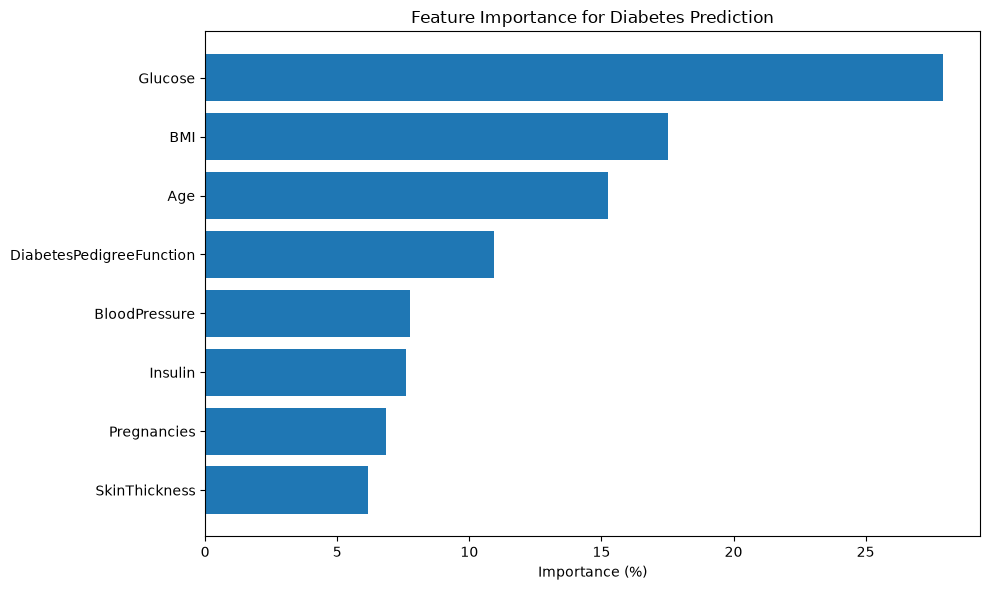

In [15]:
# Random Forest Classifier
features = diabet.drop(["Outcome"],axis= 1)
target = diabet["Outcome"]

# splilt data 

X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=42

)
model_rf = RandomForestClassifier(random_state=42)
# Creating model and fit
model_rf.fit(X_train , y_train)
predictions = model_rf.predict(X_test)
accuracy_rf = accuracy_score(y_test, predictions)
precision_rf = precision_score(y_test, predictions)
recall_rf = recall_score(y_test, predictions)
f1_rf = f1_score(y_test, predictions)
confusion_mat_rf = confusion_matrix(y_test, predictions)

print("=== RandomForestClassifier PERFORMANCE ===")
print(f"Accuracy:  {accuracy_rf:.1%}")
print(f"Precision: {precision_rf:.1%}")
print(f"Recall:    {recall_rf:.1%}")
print(f"F1 Score:  {f1_rf:.1%}")
print(f"Number of trees: {model_rf.n_estimators}")
print()
print('======'*30)

model_optimize = RandomForestClassifier( n_estimators = 200, # number of trees ( more better, but slower )
                                       max_depth = 10, # Indivitual tree depth
                                       min_samples_split = 5,#Tree split criteria
                                      min_samples_leaf=2, # 
                                       max_features= 'sqrt', # features per tree(default for classification)
                                       bootstrap= True, # sampler with replacement
                                       random_state = 42)

model_optimize.fit(X_train , y_train)
predictions_optimized = model_optimize.predict(X_test)
accuracy_optimized = accuracy_score(y_test, predictions_optimized)
precision_optimized = precision_score(y_test, predictions_optimized)
recall_optimized = recall_score(y_test, predictions_optimized)
f1_optimized = f1_score(y_test, predictions_optimized)
confusion_mat_optimized = confusion_matrix(y_test, predictions_optimized)

print("=== OPTIMIZED RANDOM FOREST PERFORMANCE ===")
print(f"Accuracy:  {accuracy_optimized:.1%}")
print(f"Precision: {precision_optimized:.1%}")
print(f"Recall:    {recall_optimized:.1%}")
print(f"F1 Score:  {f1_optimized:.1%}")
print()
print("Hyperparameters used:")
print(f"Number of trees: {model_optimize.n_estimators}")
print(f"Max Depth: {model_optimize.max_depth}")
print(f"Min Samples Split: {model_optimize.min_samples_split}")
print(f"Min Samples Leaf: {model_optimize.min_samples_leaf}")
print(f"Max Features: {model_optimize.max_features}")
print()
print('======'*30)

# Feature importance
# Train your best Random Forest model
model_best = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42
)
model_best.fit(X_train, y_train)

# Your task: Get feature importance and create visualization
feature_importance = model_best.feature_importances_
feature_names = features.columns

# Create feature importance summary
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance,
    'Importance_Percent': feature_importance * 100
}).sort_values('Importance', ascending=False)

print("=== FEATURE IMPORTANCE ANALYSIS ===")
print()
print("Medical indicators ranked by importance for diabetes prediction:")
print(importance_df.round(4))
print()
print("Top 3 Most Important Health Indicators:")
for i in range(3):
    feature = importance_df.iloc[i]['Feature']
    percent = importance_df.iloc[i]['Importance_Percent']
    print(f"{i+1}. {feature}: {percent:.1f}% importance")

# Create visualization
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance_Percent'])
plt.xlabel('Importance (%)')
plt.title('Feature Importance for Diabetes Prediction')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()